# By demo
Small demo to verify if feature `by` works correclty

In [1]:
from lpspline import bs, LpRegressor, l, pwl, cs
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from lpspline.datasets import load_by_dataset
from lpspline.constraints import Monotonic, Concave, Convex, Anchor

In [2]:
X, y = load_by_dataset(samples=1000)


x = np.linspace(-5, 10, 1000)
by = np.random.randint(low=0, high=3, size=1000)

X = pl.DataFrame({
    'x': x,
    'by': by
})
y = pl.Series(
    x**3 * (1+by) + np.random.normal(size=1000)
)

In [3]:
model = (
    #+l(term='x', tag='s', by='by').add_constraint(Monotonic(decreasing=False, start=-10, end=0))
    #+pwl(term='x',tag='s', knots = [-4, 0, 4, 8, 12], by='by').add_constraint(Monotonic(decreasing=True, start=-10, end=0))
    +bs(term='x', tag='s', knots = 4, degree=3, by='by').add_constraint(Monotonic(decreasing=True, start=-10, end=0))
    #+cs(term='x', tag='s', order=10, by='by')
)


model.fit(X, y)


✨ Model Summary ✨
Problem Status: ✅ optimal
------------------------------------------------------------------------------------------------------------------------
Spline Type          | Term         | Tag             | Constraints          | Penalties            | Params  
------------------------------------------------------------------------------------------------------------------------
🟢 BSpline           | x            | s               | Monotonic            | None                 | 18      
------------------------------------------------------------------------------------------------------------------------
📊 Total Parameters                                                                                 | 18



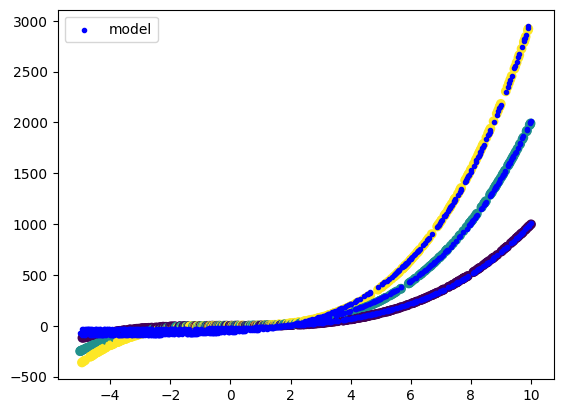

In [4]:
plt.scatter(X['x'], y, c=X['by'])
plt.scatter(X['x'], model.predict(X), color='blue', marker='.', label='model')
plt.legend()
plt.show()
